 Step 1 — ROC Curve
- Definition: ROC (Receiver Operating Characteristic) curve shows the trade‑off between True Positive Rate (Recall) and False Positive Rate at different probability thresholds.
- Layman analogy: Imagine adjusting the sensitivity of a smoke detector. If it’s too sensitive, it gives false alarms (false positives). If it’s not sensitive enough, it misses real fires (false negatives). The ROC curve shows this balance.

 Step 2 — AUC (Area Under Curve)
- Definition: AUC measures the overall ability of the model to distinguish between classes.
- Range: 0.5 (random guessing) to 1.0 (perfect classification).
- Layman analogy: AUC is like a scorecard — the closer to 1, the better your detector is at separating smoke from no smoke.


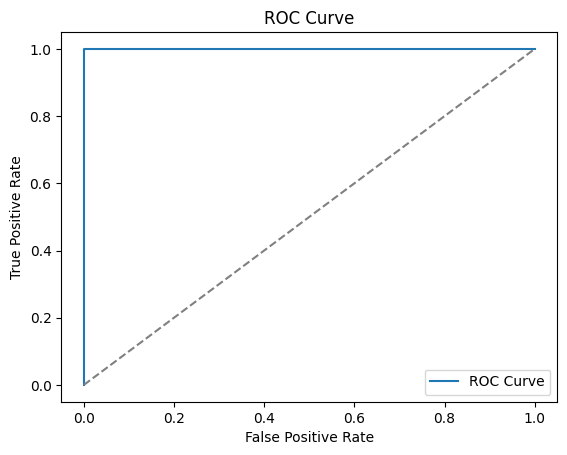

AUC Score: 1.0


In [1]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# Load dataset
iris = load_iris()
X = iris.data
y = (iris.target == 0).astype(int)  # Binary classification: setosa vs not setosa

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Logistic Regression model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# Get predicted probabilities for positive class
y_probs = model.predict_proba(X_test)[:,1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1],[0,1],'--', color='gray')  # Random baseline
plt.xlabel("False Positive Rate")   # False alarms
plt.ylabel("True Positive Rate")    # Correct detections
plt.title("ROC Curve")
plt.legend()
plt.show()

# AUC Score
print("AUC Score:", roc_auc_score(y_test, y_probs))  # Overall score of detector